Optimization finished.


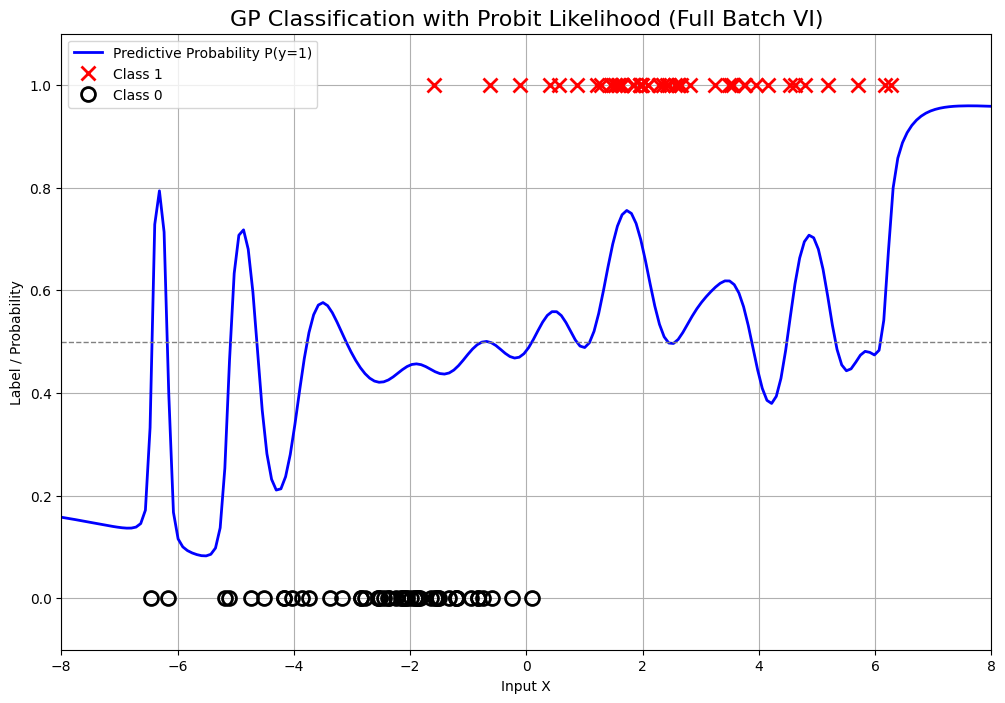

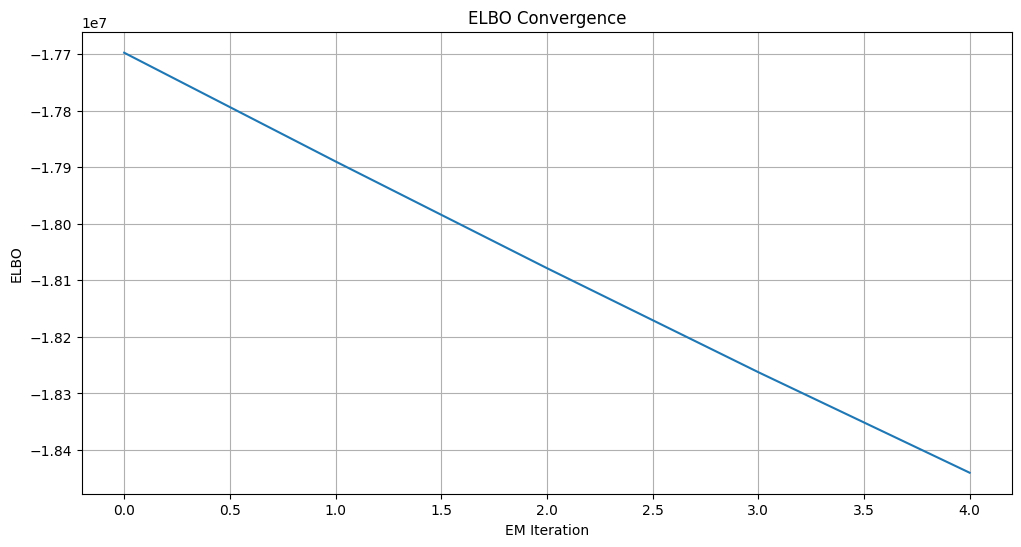

Final training accuracy: 0.8500


In [ ]:
import torch
import torch.nn as nn
import math


# --- カーネル関数の定義 ---
def rbf_kernel(X1, X2, lengthscale, variance):
    """RBFカーネル（二乗指数カーネル）を計算します。"""
    # 距離の二乗を計算
    # (x-y)^2 = x^2 - 2xy + y^2
    X1_sq = torch.sum(X1**2, dim=1, keepdim=True)
    X2_sq = torch.sum(X2**2, dim=1, keepdim=True)
    cross_term = -2 * (X1 @ X2.T)
    sq_dist = X1_sq + X2_sq.T + cross_term

    # カーネル値を計算
    return variance * torch.exp(-0.5 * sq_dist / lengthscale**2)

class GPProbitFullBatch(nn.Module):
    """
    補助変数と変分EMアルゴリズムを用いた、
    フルバッチ（非スパース）ガウス過程分類（Probit尤度）モデル。
    """
    def __init__(self, X, y, kernel_lengthscale=1.0, kernel_variance=1.0):
        super().__init__()

        self.X = X
        # yは{0, 1}のラベルと仮定し、内部で{-1, 1}に変換
        self.t = (y.view(-1, 1) * 2 - 1).to(X.dtype)
        self.N, self.D = X.shape

        # --- ハイパーパラメータ（対数空間で保存し、最適化対象とする） ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- 変分パラメータ（CAVIで更新） ---
        # q(f) = N(m_f, S_f = L_f @ L_f.T)
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)
        self.L_f = torch.eye(self.N, dtype=X.dtype, device=X.device)

        # q(z)のモーメントはCAVIステップ内で計算される
        self.E_z = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)
        self.E_z_sq = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)

        # 標準正規分布のPDFとCDFのための定数
        self.SQRT_2PI = math.sqrt(2 * math.pi)
        self.normal_dist = torch.distributions.Normal(0, 1)

    def _get_hyperparams(self):
        """対数空間のパラメータから正のハイパーパラメータを取得します。"""
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
        }

    def _update_q_z_moments(self):
        """CAVI更新：q(z_i)のモーメントを計算します。"""
        mu_f = self.m_f

        # t_i * mu_f_i を計算
        t_mu = self.t * mu_f

        # 標準正規分布のPDFとCDFを計算
        pdf_val = torch.exp(self.normal_dist.log_prob(t_mu))
        cdf_val = self.normal_dist.cdf(t_mu).clamp(min=1e-9)

        ratio = pdf_val / cdf_val

        # E[z_i] の更新
        self.E_z = mu_f + self.t * ratio

        # E[z_i^2] の更新
        var_z = 1.0 - ratio * (ratio + t_mu)
        self.E_z_sq = self.E_z.pow(2) + var_z

    def _update_q_f(self, Kxx_inv):
        """CAVI更新：q(f)のパラメータを更新します。"""
        # S_f_inv = Kxx_inv + I (ノイズの精度が1なので)
        S_f_inv = Kxx_inv + torch.eye(self.N, device=self.X.device)

        # S_f = S_f_inv^-1 をコレスキー分解経由で安定的に計算
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(
            torch.eye(self.N, device=self.X.device), L_f_inv, upper=False
        )[0]

        # m_f = S_f @ E[z]
        self.m_f = (self.L_f @ self.L_f.T) @ self.E_z

    def _cavi_step(self, Kxx_inv):
        """1回のCAVI更新サイクル。"""
        self._update_q_z_moments()
        self._update_q_f(Kxx_inv)

    def _e_step(self, cavi_max_iter=10, cavi_tol=1e-5):
        """Eステップ：CAVI更新を収束するまで実行します。"""
        with torch.no_grad():
            params = self._get_hyperparams()

            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)
            Kxx_inv = torch.cholesky_inverse(Lxx)

            for i in range(cavi_max_iter):
                m_f_prev = self.m_f.clone()
                self._cavi_step(Kxx_inv)

                # 収束判定
                rel_change = torch.norm(self.m_f - m_f_prev) / (torch.norm(m_f_prev) + 1e-8)
                if rel_change < cavi_tol:
                    break

    def _calculate_elbo(self):
        """証拠下限（ELBO）を計算します。"""
        params = self._get_hyperparams()
        Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
        Lxx = torch.linalg.cholesky(Kxx)
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f = self.L_f @ self.L_f.T

        # 1. E[log p(z|f)]
        expected_sq_error = self.E_z_sq - 2 * self.E_z * self.m_f + (self.m_f.pow(2) + S_f.diag().unsqueeze(1))
        e_log_lik_z = -0.5 * self.N * math.log(2 * math.pi) - 0.5 * torch.sum(expected_sq_error)

        # 2. KL[q(f) || p(f)]
        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        log_det_S_f = 2 * torch.sum(torch.log(torch.diag(self.L_f)))

        kl_f = 0.5 * (
            log_det_Kxx - log_det_S_f - self.N +
            torch.trace(Kxx_inv @ S_f) +
            self.m_f.T @ Kxx_inv @ self.m_f
        )

        # 3. H[q(z)] (エントロピー)
        mu_f = self.m_f
        t_mu = self.t * mu_f

        cdf_val = self.normal_dist.cdf(t_mu).clamp(min=1e-9)
        pdf_val = torch.exp(self.normal_dist.log_prob(t_mu))
        ratio = pdf_val / cdf_val

        entropy_z = 0.5 * math.log(2 * math.pi * math.e) + torch.log(cdf_val) - 0.5 * t_mu * ratio
        H_z = torch.sum(entropy_z)

        # ELBO = E[log p(z|f)] - KL[q(f)||p(f)] + H[q(z)]
        elbo = e_log_lik_z - kl_f.squeeze() + H_z
        return elbo

    def _m_step(self, optimizer):
        """Mステップ：ハイパーパラメータを更新します。"""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, cavi_tol=1e-10, lr=0.01):
        """変分EMアルゴリズムでモデルを学習させます。"""
        optimizer = torch.optim.Adam([
            self.log_kernel_lengthscale, self.log_kernel_variance
        ], lr=lr)

        elbo_history = []
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)

            if (i + 1) % 10 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")

        print("Optimization finished.")
        return elbo_history

    def predict(self, X_test):
        """新しいテスト点 X_test での予測確率を計算します。"""
        with torch.no_grad():
            params = self._get_hyperparams()

            # 必要なカーネル行列を計算
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance'])
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # 予測分布 q(f_*) のモーメントを計算
            # Mean: E[f_*] = K_*x @ Kxx^-1 @ m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean_f = K_star_x @ Kxx_inv_mf

            # Variance: Var[f_*]
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_K_x_star = torch.cholesky_solve(K_star_x.T, Lxx)

            var_f = K_star_star.diag() - (K_star_x * Kxx_inv_K_x_star.T).sum(dim=1) + \
                    (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_K_x_star, Lxx)).diag()

            # 予測確率 P(t_*=1) = Phi( E[f_*] / sqrt(1 + Var[f_*]) )
            pred_prob = self.normal_dist.cdf(
                pred_mean_f.squeeze() / torch.sqrt(1 + var_f.clamp(min=1e-9))
            )

            return pred_prob.unsqueeze(1)

    def evaluate(self, X_test, y_test):
        """テストデータでモデルの性能（正解率）を評価します。"""
        with torch.no_grad():
            pred_probs = self.predict(X_test)
            pred_labels = (pred_probs > 0.5).float()
            accuracy = (pred_labels.squeeze() == y_test.squeeze()).float().mean()
            return accuracy.item()

# --- メインの実行ブロック（テスト用） ---
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    torch.manual_seed(42)
    torch.set_default_dtype(torch.float64)

    # 1. データ生成 (2つのクラスが混ざり合ったデータ)
    N1, N2 = 50, 50
    N = N1 + N2
    X1 = torch.randn(N1, 1) * 1.5 - 2.5
    X2 = torch.randn(N2, 1) * 1.5 + 2.5
    X_train = torch.cat([X1, X2])
    y_train = torch.cat([torch.zeros(N1), torch.ones(N2)])

    # データをシャッフル
    perm = torch.randperm(N)
    X_train = X_train[perm]
    y_train = y_train[perm]

    # 2. モデルのセットアップ
    model = GPProbitFullBatch(X=X_train, y=y_train)

    # 3. モデルの学習
    elbo_history = model.fit(max_iter_global=5, cavi_max_iter=1000, lr=0.01)

    # 4. 予測と可視化
    X_test = torch.linspace(-8, 8, 200).unsqueeze(1)
    pred_probs = model.predict(X_test)

    # 5. 結果のプロット
    plt.figure(figsize=(12, 8))
    plt.plot(X_test, pred_probs, 'b-', lw=2, label='Predictive Probability P(y=1)')

    # 決定境界
    plt.axhline(0.5, color='gray', linestyle='--', lw=1)

    # データをプロット
    plt.plot(X_train[y_train == 1], y_train[y_train == 1], 'rx', ms=10, mew=2, label='Class 1')
    plt.plot(X_train[y_train == 0], y_train[y_train == 0], 'ko', mfc='none', ms=10, mew=2, label='Class 0')

    plt.title('GP Classification with Probit Likelihood (Full Batch VI)', fontsize=16)
    plt.xlabel('Input X')
    plt.ylabel('Label / Probability')
    plt.legend()
    plt.grid(True)
    plt.ylim(-0.1, 1.1)
    plt.xlim(-8, 8)

    # ELBOの収束プロット
    plt.figure(figsize=(12, 6))
    plt.plot(elbo_history)
    plt.title("ELBO Convergence")
    plt.xlabel("EM Iteration")
    plt.ylabel("ELBO")
    plt.grid(True)

    plt.show()

    # 評価
    accuracy = model.evaluate(X_train, y_train)
    print(f"Final training accuracy: {accuracy:.4f}")

変分推論を開始します...
Iteration   1, Change in m: 6.265731
Iteration  11, Change in m: 0.049000
Iteration  21, Change in m: 0.001582
Iteration  31, Change in m: 0.000057
収束しました (Iteration: 37)


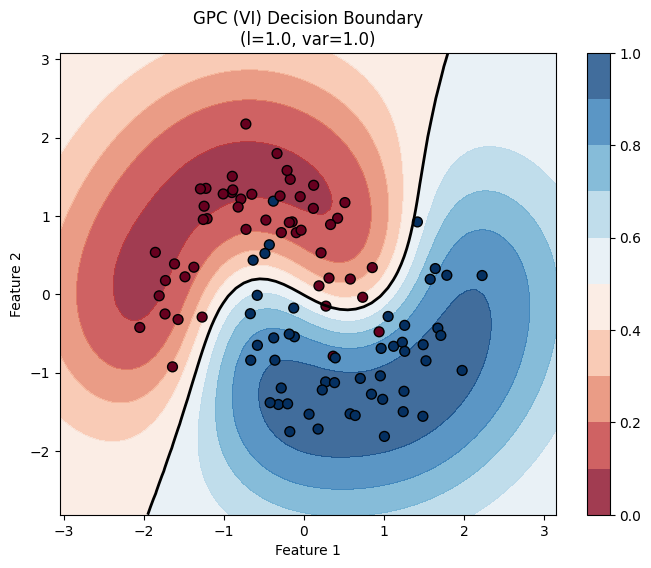

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.linalg import inv, cholesky, cho_solve
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# 数値計算の安定性のための小さな値
JITTER = 1e-6

def rbf_kernel(X1, X2, length_scale=1.0, variance=1.0):
    """
    RBFカーネル（ガウスカーネル）を計算します。

    Args:
        X1 (np.ndarray): 入力データ1 (N1 x D)
        X2 (np.ndarray): 入力データ2 (N2 x D)
        length_scale (float): カーネルの長さスケール
        variance (float): カーネルの分散

    Returns:
        np.ndarray: カーネル行列 (N1 x N2)
    """
    # 各点間の平方ユークリッド距離を計算
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return variance * np.exp(-0.5 / length_scale**2 * sqdist)

def get_truncnorm_moments(y, mu):
    """
    切断正規分布の1次と2次のモーメント（期待値と二乗期待値）を計算します。
    分布は N(z | mu, 1) で、y=+1なら z>0、y=-1なら z<0 の範囲で切断されます。

    Args:
        y (np.ndarray): クラスラベル (+1 or -1), (N,)
        mu (np.ndarray): 切断前の正規分布の平均, (N,)

    Returns:
        tuple[np.ndarray, np.ndarray]: (期待値 E[z], 期待値の二乗 E[z^2])
    """
    # 数値的安定性のために y*mu の符号を考慮
    alpha = y * mu

    # 標準正規分布のPDFとCDF
    pdf_alpha = norm.pdf(alpha)
    cdf_alpha = norm.cdf(alpha)

    # ゼロ除算を避ける
    cdf_alpha[cdf_alpha < 1e-10] = 1e-10

    # 切断正規分布のモーメント計算式
    # E[z] = mu + y * pdf(alpha) / cdf(alpha)
    # Var[z] = 1 - (pdf(alpha)/cdf(alpha)) * (alpha + pdf(alpha)/cdf(alpha))

    ratio = pdf_alpha / cdf_alpha

    # 期待値 E[z]
    exp_z = mu + y * ratio

    # 分散 Var[z]
    var_z = 1 - ratio * (alpha + ratio)

    # 期待値の二乗 E[z^2] = Var[z] + E[z]^2
    exp_z_sq = var_z + exp_z**2

    return exp_z, exp_z_sq


class GPC_VI:
    """
    ガウス過程分類（プロビット尤度）の変分推論モデル
    """
    def __init__(self, length_scale=1.0, variance=1.0):
        """
        コンストラクタ

        Args:
            length_scale (float): RBFカーネルの長さスケール
            variance (float): RBFカーネルの分散
        """
        self.length_scale = length_scale
        self.variance = variance

        # 学習済みパラメータを保持する変数
        self.X_train_ = None
        self.y_train_ = None
        self.m_ = None  # q(f)の平均
        self.S_ = None  # q(f)の共分散
        self.K_inv_ = None

    def fit(self, X, y, n_iters=100, tol=1e-5):
        """
        変分推論を用いてモデルを学習します。

        Args:
            X (np.ndarray): 学習データ (N x D)
            y (np.ndarray): 学習ラベル (0 or 1), (N,)
            n_iters (int): 最大イテレーション回数
            tol (float): 収束判定の閾値
        """
        N, D = X.shape
        self.X_train_ = X

        # ラベルを {0, 1} から {-1, +1} に変換
        self.y_train_ = 2 * y - 1

        # カーネル行列 K とその逆行列 K_inv を計算
        K = rbf_kernel(X, X, self.length_scale, self.variance) + JITTER * np.eye(N)
        # self.K_inv_ = inv(K) # 通常の逆行列
        # より数値的に安定なコレスキー分解を用いる
        L = cholesky(K, lower=True)
        self.K_inv_ = cho_solve((L, True), np.eye(N))


        # M-Stepで更新される q(f) の共分散 S はこのモデルでは固定
        # S = (K_inv + I)^-1
        self.S_ = inv(self.K_inv_ + np.eye(N))

        # q(f)の平均 m をゼロで初期化
        self.m_ = np.zeros(N)

        print("変分推論を開始します...")
        for i in range(n_iters):
            m_old = self.m_.copy()

            # --- E-Step: q(z) の更新 ---
            # 現在の q(f) の平均 m を用いて、q(z) のモーメントを計算
            E_z, _ = get_truncnorm_moments(self.y_train_, self.m_)

            # --- M-Step: q(f) の更新 ---
            # q(z) の期待値 E_z を用いて、q(f) の平均 m を更新
            self.m_ = self.S_ @ E_z

            # --- 収束判定 ---
            diff = np.linalg.norm(self.m_ - m_old)
            if i % 10 == 0:
                print(f"Iteration {i+1:3d}, Change in m: {diff:.6f}")
            if diff < tol:
                print(f"収束しました (Iteration: {i+1})")
                break
        else:
            print("最大イテレーション回数に達しました。")


    def predict_proba(self, X_test):
        """
        新しいデータ点に対するクラス1の予測確率を計算します。

        Args:
            X_test (np.ndarray): テストデータ (N_test x D)

        Returns:
            np.ndarray: クラス1に属する確率 (N_test,)
        """
        if self.m_ is None:
            raise RuntimeError("モデルが学習されていません。.fit()を先に呼び出してください。")

        # テストデータと学習データの間のカーネル k_*
        k_star = rbf_kernel(self.X_train_, X_test, self.length_scale, self.variance)
        # テストデータ間のカーネル（対角成分のみ） k_**
        k_star_star = rbf_kernel(X_test, X_test, self.length_scale, self.variance).diagonal()

        # 予測分布 q(f_*) の平均を計算
        # E_q[f_*] = k_*^T K^-1 m
        m_star = k_star.T @ self.K_inv_ @ self.m_

        # 予測分布 q(f_*) の分散を計算
        # Var_q[f_*] = k_** - k_*^T K^-1 k_* + k_*^T K^-1 S K^-1 k_*
        K_inv_k_star = self.K_inv_ @ k_star
        var_star = k_star_star - np.sum(k_star * K_inv_k_star, axis=0) \
                   + np.sum((K_inv_k_star.T @ self.S_) * K_inv_k_star.T, axis=1)

        # 予測確率を計算
        # p(y_*=1 | D) ≈ Φ( E_q[f_*] / sqrt(1 + Var_q[f_*]) )
        prob = norm.cdf(m_star / np.sqrt(1 + var_star))

        return prob

def plot_decision_boundary(model, X, y, ax):
    """決定境界と予測確率をプロットする関数"""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid_points)
    Z = Z.reshape(xx.shape)

    # 確率のコンタープロット
    cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8, levels=np.linspace(0, 1, 11))
    plt.colorbar(cs, ax=ax)

    # 決定境界 (p=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    # 学習データをプロット
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=50)
    ax.set_title(f"GPC (VI) Decision Boundary\n(l={model.length_scale}, var={model.variance})")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

if __name__ == '__main__':
    # 1. データの生成と前処理
    X, y = make_moons(n_samples=100, noise=0.2, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. モデルのインスタンス化と学習
    # カーネルのハイパーパラメータはデータの特性に合わせて調整する必要がある
    gpc_vi = GPC_VI(length_scale=1.0, variance=1.0)
    gpc_vi.fit(X_scaled, y, n_iters=100)

    # 3. 結果の可視化
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    plot_decision_boundary(gpc_vi, X_scaled, y, ax)
    plt.show()

ハイパーパラメータ最適化を開始します...
Iter  10/50 | ELBO:    52.11 | l: 0.733 | var: 1.539
Iter  20/50 | ELBO:    50.91 | l: 0.899 | var: 2.193
Iter  30/50 | ELBO:    50.57 | l: 0.913 | var: 2.953
Iter  40/50 | ELBO:    50.53 | l: 0.945 | var: 3.368
Iter  50/50 | ELBO:    50.53 | l: 0.952 | var: 3.448
学習が完了しました。


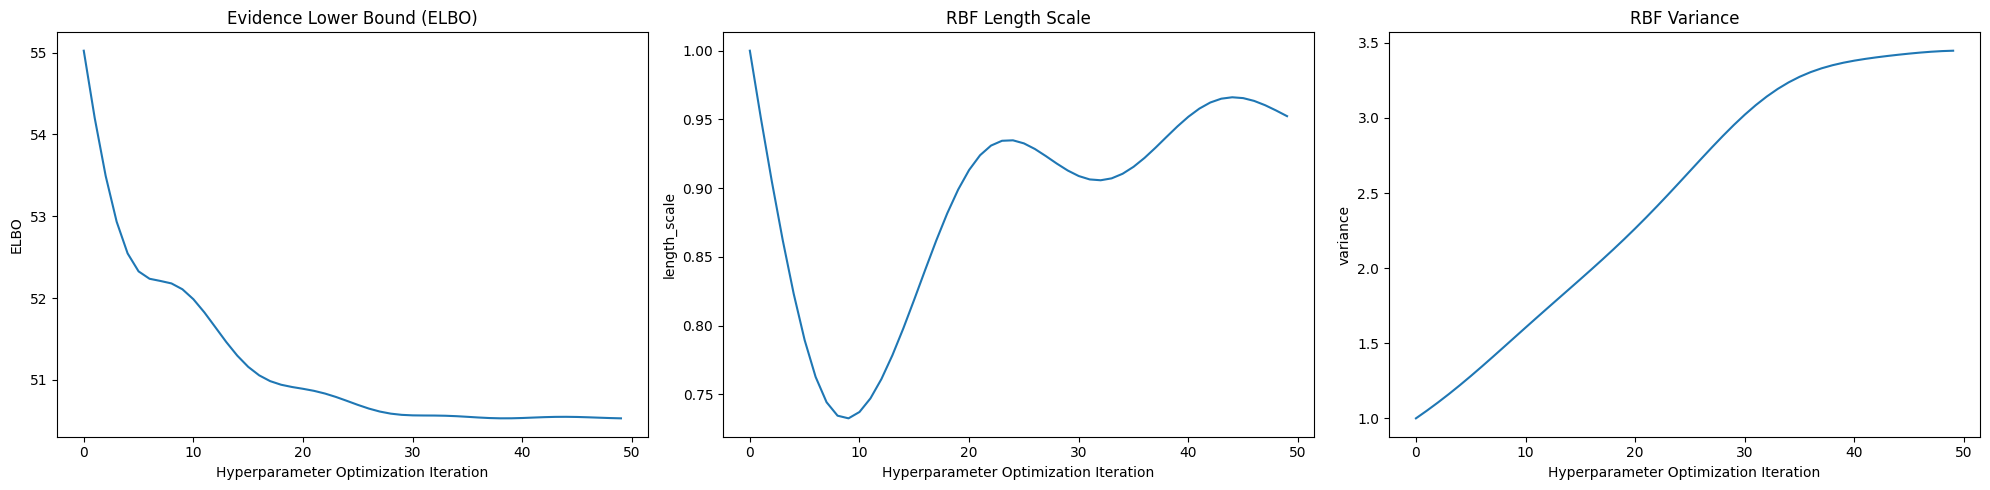

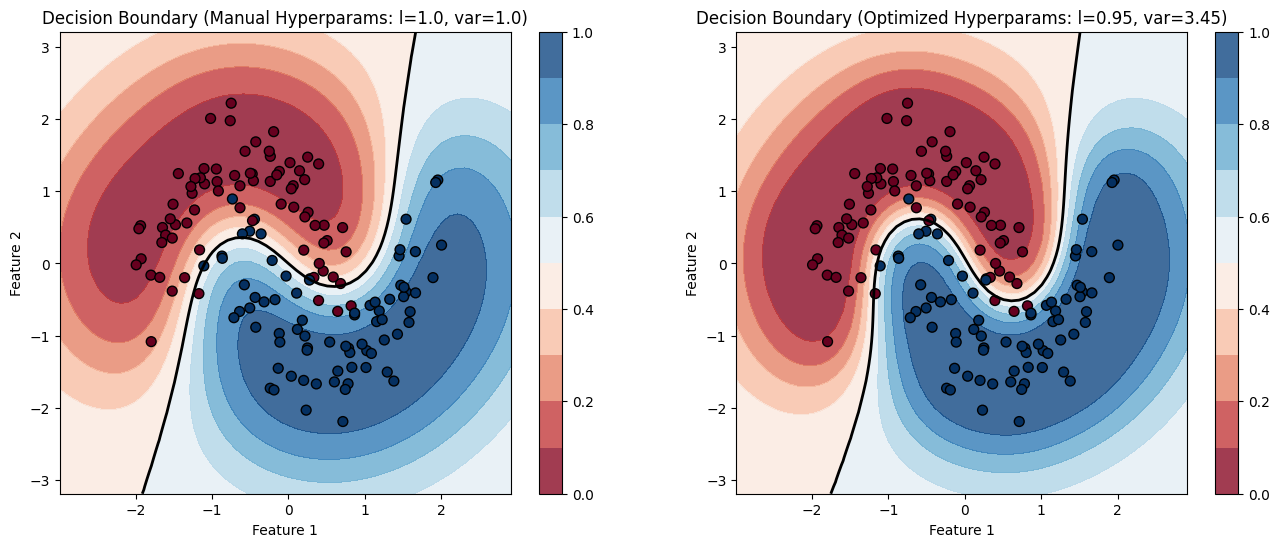

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.stats import norm
from jax.scipy.linalg import cholesky, cho_solve
import optax # JAXのためのオプティマイザライブラリ

import numpy as np # JAX以外の部分（プロットなど）で使用
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# JAXのデフォルトを64ビット浮動小数点数に設定（数値安定性のため）
jax.config.update("jax_enable_x64", True)

# 数値計算の安定性のための小さな値
JITTER = 1e-6

# --- JAXで実装されたヘルパー関数 ---

@jax.jit
def rbf_kernel(X1, X2, length_scale, variance):
    """JAXで実装されたRBFカーネル"""
    sqdist = jnp.sum(X1**2, 1).reshape(-1, 1) + jnp.sum(X2**2, 1) - 2 * jnp.dot(X1, X2.T)
    return variance * jnp.exp(-0.5 / length_scale**2 * sqdist)

@jax.jit
def get_truncnorm_moments(y, mu):
    """JAXで実装された切断正規分布のモーメント計算"""
    alpha = y * mu
    pdf_alpha = norm.pdf(alpha)
    cdf_alpha = norm.cdf(alpha)
    # ゼロ除算を避けるためのクリッピング
    cdf_alpha = jnp.maximum(cdf_alpha, 1e-12)
    ratio = pdf_alpha / cdf_alpha

    exp_z = mu + y * ratio
    var_z = 1 - ratio * (alpha + ratio)
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

@jax.jit
def get_truncnorm_entropy(y, mu):
    """JAXで実装された切断正規分布のエントロピー計算"""
    alpha = y * mu
    pdf_alpha = norm.pdf(alpha)
    cdf_alpha = norm.cdf(alpha)
    cdf_alpha = jnp.maximum(cdf_alpha, 1e-12)

    # 切断正規分布のエントロピーの解析解
    H = jnp.log(jnp.sqrt(2 * jnp.pi * jnp.e) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H

class GPC_VI_HyperOpt:
    """
    ガウス過程分類（VI）モデル
    ELBO最大化によるハイパーパラメータ最適化機能付き
    """
    def __init__(self, n_cavi_iters=10, cavi_tol=1e-5):
        self.n_cavi_iters = n_cavi_iters
        self.cavi_tol = cavi_tol

        # 学習済みパラメータ
        self.X_train_, self.y_train_ = None, None
        self.hyperparams_ = None # 学習済みハイパーパラメータ
        self.m_, self.S_ = None, None # 学習済み変分パラメータ

    def _cavi_fit(self, X, y, K, K_inv):
        """内部CAVIループ: 変分パラメータを最適化"""
        N = X.shape[0]
        S = jnp.linalg.inv(K_inv + jnp.eye(N))
        m = jnp.zeros(N)

        for _ in range(self.n_cavi_iters):
            m_old = m
            # E-Step: q(z)の更新とモーメント計算
            E_z, _ = get_truncnorm_moments(y, m)
            # M-Step: q(f)の更新
            m = S @ E_z
            if jnp.linalg.norm(m - m_old) < self.cavi_tol:
                break
        return m, S

    def _elbo(self, hyperparams, X, y, m, S):
        """ELBOを計算する関数"""
        N = X.shape[0]
        l = hyperparams['length_scale']
        var = hyperparams['variance']

        K = rbf_kernel(X, X, l, var) + JITTER * jnp.eye(N)
        L = cholesky(K, lower=True)
        K_inv = cho_solve((L, True), jnp.eye(N))

        # 1. KLダイバージェンス D_KL(q(f) || p(f))
        log_det_K = 2 * jnp.sum(jnp.log(jnp.diag(L)))
        _, log_det_S = jnp.linalg.slogdet(S)
        kl_f = 0.5 * (jnp.trace(K_inv @ S) + m.T @ K_inv @ m - N + log_det_K - log_det_S)

        # 2. 期待値項 E[log p(z|f)]
        E_z, E_z_sq = get_truncnorm_moments(y, m)
        exp_log_lik = -0.5 * jnp.sum(E_z_sq - 2 * E_z * m + jnp.diag(S) + m**2) - 0.5 * N * jnp.log(2 * jnp.pi)

        # 3. エントロピー H(q(z))
        entropy_q_z = jnp.sum(get_truncnorm_entropy(y, m))

        elbo = exp_log_lik - kl_f + entropy_q_z
        return elbo

    def fit(self, X, y, n_hyper_iters=50, learning_rate=0.01):
        """CAVIと勾配法を組み合わせたハイブリッド学習"""
        self.X_train_ = jnp.array(X)
        self.y_train_ = jnp.array(2 * y - 1) # ラベルを {-1, +1} に

        # ハイパーパラメータの初期化（対数空間で扱うと安定しやすい）
        log_hyperparams = {
            'length_scale': jnp.log(1.0),
            'variance': jnp.log(1.0)
        }

        # Adamオプティマイザの初期化
        optimizer = optax.adam(learning_rate)
        opt_state = optimizer.init(log_hyperparams)

        # ELBOと勾配を計算する関数をJAXで作成
        elbo_and_grad_fn = jax.value_and_grad(self._elbo, argnums=0)

        history = {'elbo': [], 'length_scale': [], 'variance': []}

        print("ハイパーパラメータ最適化を開始します...")
        for i in range(n_hyper_iters):
            # 現在のハイパーパラメータ（対数スケールから通常スケールへ）
            hyperparams = {k: jnp.exp(v) for k, v in log_hyperparams.items()}

            # --- 内部ループ: CAVI ---
            K = rbf_kernel(self.X_train_, self.X_train_, hyperparams['length_scale'], hyperparams['variance']) + JITTER * jnp.eye(X.shape[0])
            L = cholesky(K, lower=True)
            K_inv = cho_solve((L, True), jnp.eye(X.shape[0]))
            m, S = self._cavi_fit(self.X_train_, self.y_train_, K, K_inv)

            # --- 外部ループ: 勾配計算と更新 ---
            elbo, grads = elbo_and_grad_fn(hyperparams, self.X_train_, self.y_train_, m, S)

            # 対数スケールでの勾配に変換 (chain rule: d/d(log_p) = d/dp * dp/d(log_p) = d/dp * p)
            log_grads = {k: grads[k] * hyperparams[k] for k in grads}

            updates, opt_state = optimizer.update(log_grads, opt_state)
            log_hyperparams = optax.apply_updates(log_hyperparams, updates)

            # 履歴の保存
            history['elbo'].append(elbo)
            history['length_scale'].append(hyperparams['length_scale'])
            history['variance'].append(hyperparams['variance'])

            if (i+1) % 10 == 0:
                print(f"Iter {i+1:3d}/{n_hyper_iters} | ELBO: {elbo:8.2f} | "
                      f"l: {hyperparams['length_scale']:.3f} | var: {hyperparams['variance']:.3f}")

        # 学習済みの最終パラメータを保存
        self.hyperparams_ = {k: jnp.exp(v) for k, v in log_hyperparams.items()}
        K = rbf_kernel(self.X_train_, self.X_train_, self.hyperparams_['length_scale'], self.hyperparams_['variance']) + JITTER * jnp.eye(X.shape[0])
        L = cholesky(K, lower=True)
        K_inv = cho_solve((L, True), jnp.eye(X.shape[0]))
        self.m_, self.S_ = self._cavi_fit(self.X_train_, self.y_train_, K, K_inv)

        print("学習が完了しました。")
        return history

    def predict_proba(self, X_test):
        """予測確率の計算"""
        if self.m_ is None:
            raise RuntimeError("モデルが学習されていません。.fit()を先に呼び出してください。")

        X_test = jnp.array(X_test)
        l = self.hyperparams_['length_scale']
        var = self.hyperparams_['variance']

        K = rbf_kernel(self.X_train_, self.X_train_, l, var) + JITTER * jnp.eye(self.X_train_.shape[0])
        L = cholesky(K, lower=True)
        K_inv = cho_solve((L, True), jnp.eye(self.X_train_.shape[0]))

        k_star = rbf_kernel(self.X_train_, X_test, l, var)
        k_star_star = rbf_kernel(X_test, X_test, l, var).diagonal()

        m_star = k_star.T @ K_inv @ self.m_

        K_inv_k_star = K_inv @ k_star
        var_star = k_star_star - jnp.sum(k_star * K_inv_k_star, axis=0) \
                   + jnp.sum((K_inv_k_star.T @ self.S_) * K_inv_k_star.T, axis=1)

        prob = norm.cdf(m_star / jnp.sqrt(1 + var_star))
        return np.array(prob) # 結果をNumPy配列に戻す

# --- 可視化関数 (変更なし) ---
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid_points)
    Z = Z.reshape(xx.shape)
    cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8, levels=np.linspace(0, 1, 11))
    plt.colorbar(cs, ax=ax)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=50)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    # ELBO
    axes[0].plot(history['elbo'])
    axes[0].set_title('Evidence Lower Bound (ELBO)')
    axes[0].set_xlabel('Hyperparameter Optimization Iteration')
    axes[0].set_ylabel('ELBO')
    # Length Scale
    axes[1].plot(history['length_scale'])
    axes[1].set_title('RBF Length Scale')
    axes[1].set_xlabel('Hyperparameter Optimization Iteration')
    axes[1].set_ylabel('length_scale')
    # Variance
    axes[2].plot(history['variance'])
    axes[2].set_title('RBF Variance')
    axes[2].set_xlabel('Hyperparameter Optimization Iteration')
    axes[2].set_ylabel('variance')
    fig.tight_layout()
    plt.show()


if __name__ == '__main__':
    # 1. データ生成と前処理
    X, y = make_moons(n_samples=150, noise=0.2, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. モデルのインスタンス化と学習
    gpc_hyper = GPC_VI_HyperOpt(n_cavi_iters=15)

    # 手動で設定したハイパーパラメータでの結果（比較用）
    gpc_manual = GPC_VI_HyperOpt(n_cavi_iters=100)
    gpc_manual.hyperparams_ = {'length_scale': 1.0, 'variance': 1.0}
    K_manual = rbf_kernel(X_scaled, X_scaled, 1.0, 1.0) + JITTER * jnp.eye(X_scaled.shape[0])
    L_manual = cholesky(K_manual, lower=True)
    K_inv_manual = cho_solve((L_manual, True), jnp.eye(X_scaled.shape[0]))
    gpc_manual.m_, gpc_manual.S_ = gpc_manual._cavi_fit(X_scaled, 2*y-1, K_manual, K_inv_manual)
    gpc_manual.X_train_ = X_scaled

    # ELBO最大化による学習
    history = gpc_hyper.fit(X_scaled, y, n_hyper_iters=50, learning_rate=0.05)

    # 3. 学習過程と結果の可視化
    plot_history(history)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    # 手動設定の結果
    plot_decision_boundary(gpc_manual, X_scaled, y, axes[0], 'Decision Boundary (Manual Hyperparams: l=1.0, var=1.0)')
    # 最適化後の結果
    l_final = gpc_hyper.hyperparams_['length_scale']
    var_final = gpc_hyper.hyperparams_['variance']
    plot_decision_boundary(gpc_hyper, X_scaled, y, axes[1], f'Decision Boundary (Optimized Hyperparams: l={l_final:.2f}, var={var_final:.2f})')
    plt.show()

In [ ]:
! pip install cola-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.0 MB/s eta 0:00:00


CoLAを用いたハイパーパラメータ最適化を開始します...
Iter  10/50 | ELBO:   -52.11 | l: 0.733 | var: 1.539
Iter  20/50 | ELBO:   -50.91 | l: 0.899 | var: 2.193
Iter  30/50 | ELBO:   -50.57 | l: 0.913 | var: 2.953
Iter  40/50 | ELBO:   -50.53 | l: 0.945 | var: 3.368
Iter  50/50 | ELBO:   -50.53 | l: 0.952 | var: 3.448
学習が完了しました。


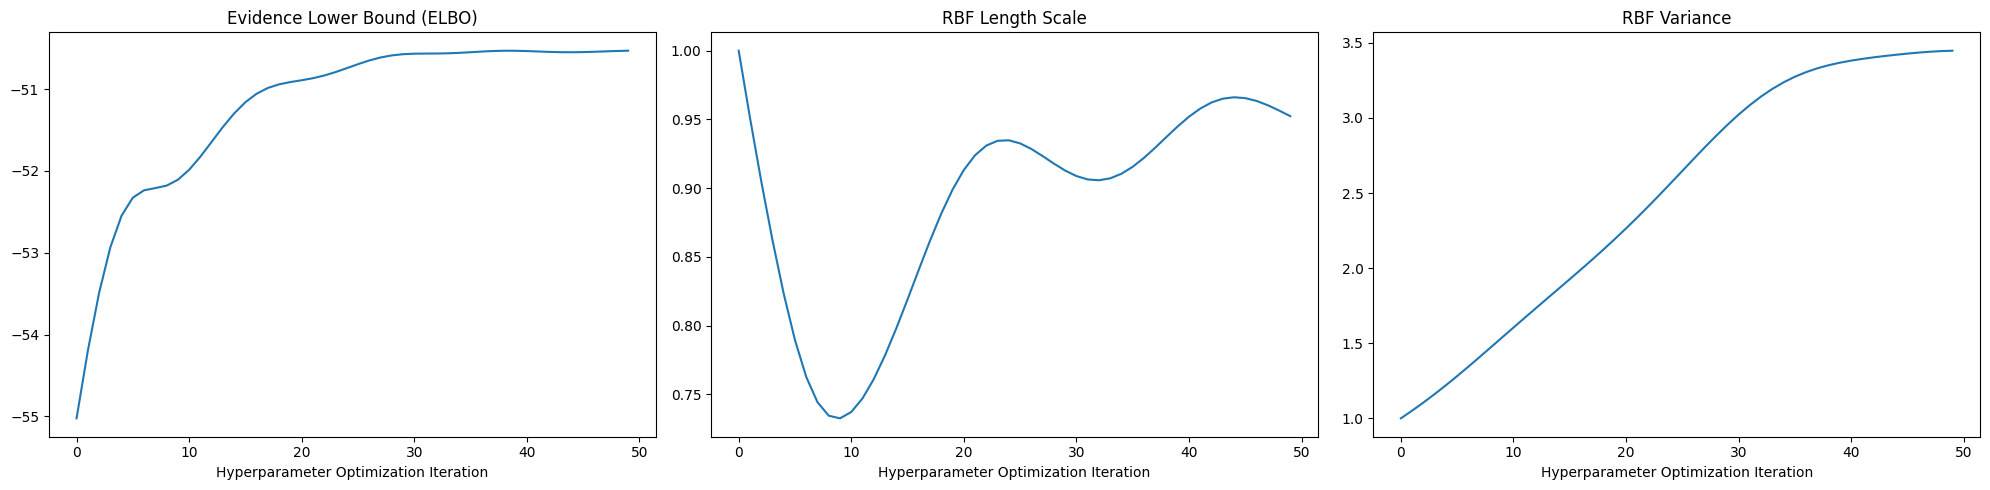

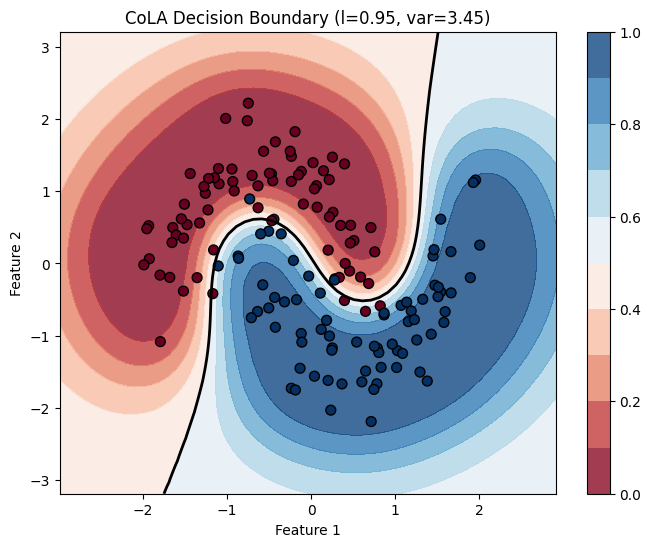

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.stats import norm
import optax

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# CoLAライブラリをインポート
import cola

# JAXのデフォルトを64ビット浮動小数点数に設定
jax.config.update("jax_enable_x64", True)


# --- JAXで実装されたヘルパー関数 (変更なし) ---
@jax.jit
def get_truncnorm_moments(y, mu):
    alpha = y * mu
    pdf_alpha = norm.pdf(alpha)
    cdf_alpha = norm.cdf(alpha)
    cdf_alpha = jnp.maximum(cdf_alpha, 1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * ratio
    var_z = 1 - ratio * (alpha + ratio)
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

@jax.jit
def get_truncnorm_entropy(y, mu):
    alpha = y * mu
    pdf_alpha = norm.pdf(alpha)
    cdf_alpha = norm.cdf(alpha)
    cdf_alpha = jnp.maximum(cdf_alpha, 1e-12)
    H = jnp.log(jnp.sqrt(2 * jnp.pi * jnp.e) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H

# --- CoLAのためのカスタムLinearOperator ---
class RBFKernel(cola.ops.LinearOperator):
    """ CoLAのLinearOperatorとしてRBFカーネルを定義 """
    def __init__(self, X, length_scale, variance):
        super().__init__(dtype=X.dtype, shape=(X.shape[0], X.shape[0]))
        self.X = X
        self.length_scale = length_scale
        self.variance = variance

    def _matmat(self, V):
        # K @ V の計算 (Kは陽に作らない)
        X1 = self.X
        X2 = self.X
        sqdist = jnp.sum(X1**2, 1).reshape(-1, 1) + jnp.sum(X2**2, 1) - 2 * jnp.dot(X1, X2.T)
        K = self.variance * jnp.exp(-0.5 / self.length_scale**2 * sqdist)
        return K @ V

# --- CoLAを適用したGPC_VIモデル ---
class GPC_VI_CoLA:
    """
    CoLAを用いてスケーラブルにしたガウス過程分類（VI）モデル
    """
    def __init__(self, n_cavi_iters=10, cavi_tol=1e-5):
        self.n_cavi_iters = n_cavi_iters
        self.cavi_tol = cavi_tol

        self.X_train_, self.y_train_ = None, None
        self.hyperparams_ = None
        self.m_, self.S_op_ = None, None # Sを密行列ではなく演算子として保持

    def _cavi_fit_cola(self, X, y, K_op):
        """CoLA版CAVIループ: 変分パラメータを最適化"""
        N = X.shape[0]
        # S = (K_inv + I)^-1 = K @ (K + I)^-1
        # SをLinearOperatorとして定義
        I_op = cola.ops.I_like(K_op)
        S_op = K_op @ cola.inv(K_op + I_op)

        m = jnp.zeros(N, dtype=K_op.dtype)

        for _ in range(self.n_cavi_iters):
            m_old = m
            E_z, _ = get_truncnorm_moments(y, m)
            # m = S @ E_z を実行
            m = S_op @ E_z
            if jnp.linalg.norm(m - m_old) < self.cavi_tol:
                break
        return m, S_op

    def _elbo_cola(self, hyperparams, X, y, m, S_op):
        """CoLA版ELBO計算関数"""
        N = X.shape[0]
        l = hyperparams['length_scale']
        var = hyperparams['variance']

        K_op = RBFKernel(X, l, var)
        K_op = K_op + cola.ops.Identity(shape=K_op.shape, dtype=K_op.dtype) * 1e-6

        # 1. KLダイバージェンス D_KL(q(f) || p(f))
        log_det_K = cola.logdet(K_op)
        log_det_S = cola.logdet(S_op)

        K_inv_m = cola.solve(K_op, m)
        m_Kinv_m = m.T @ K_inv_m

        # 【修正】リストではなく、個別の引数として演算子を渡す
        trace_op = cola.ops.Product(cola.inv(K_op), S_op)
        trace_K_inv_S = cola.trace(trace_op)

        kl_f = 0.5 * (trace_K_inv_S + m_Kinv_m - N + log_det_K - log_det_S)

        # 2. 期待値項 E[log p(z|f)]
        E_z, E_z_sq = get_truncnorm_moments(y, m)
        diag_S = cola.diag(S_op)
        exp_log_lik = -0.5 * jnp.sum(E_z_sq - 2 * E_z * m + diag_S + m**2) - 0.5 * N * jnp.log(2 * jnp.pi)

        # 3. エントロピー H(q(z))
        entropy_q_z = jnp.sum(get_truncnorm_entropy(y, m))

        elbo = exp_log_lik - kl_f + entropy_q_z
        return -elbo #最小化問題にするため符号反転

    def fit(self, X, y, n_hyper_iters=50, learning_rate=0.01):
        """CoLA版ハイブリッド学習"""
        self.X_train_ = jnp.array(X)
        self.y_train_ = jnp.array(2 * y - 1)

        log_hyperparams = {
            'length_scale': jnp.log(1.0),
            'variance': jnp.log(1.0)
        }

        optimizer = optax.adam(learning_rate)
        opt_state = optimizer.init(log_hyperparams)

        loss_and_grad_fn = jax.value_and_grad(self._elbo_cola, argnums=0)

        history = {'elbo': [], 'length_scale': [], 'variance': []}

        print("CoLAを用いたハイパーパラメータ最適化を開始します...")
        for i in range(n_hyper_iters):
            hyperparams = {k: jnp.exp(v) for k, v in log_hyperparams.items()}

            K_op = RBFKernel(self.X_train_, hyperparams['length_scale'], hyperparams['variance'])
            K_op = K_op + cola.ops.Identity(K_op.shape, K_op.dtype) * 1e-6
            m, S_op = self._cavi_fit_cola(self.X_train_, self.y_train_, K_op)

            loss, grads = loss_and_grad_fn(hyperparams, self.X_train_, self.y_train_, m, S_op)

            log_grads = {k: grads[k] * hyperparams[k] for k in grads}
            updates, opt_state = optimizer.update(log_grads, opt_state)
            log_hyperparams = optax.apply_updates(log_hyperparams, updates)

            history['elbo'].append(-loss)
            history['length_scale'].append(hyperparams['length_scale'])
            history['variance'].append(hyperparams['variance'])

            if (i+1) % 10 == 0:
                print(f"Iter {i+1:3d}/{n_hyper_iters} | ELBO: {-loss:8.2f} | "
                      f"l: {hyperparams['length_scale']:.3f} | var: {hyperparams['variance']:.3f}")

        self.hyperparams_ = {k: jnp.exp(v) for k, v in log_hyperparams.items()}
        K_op_final = RBFKernel(self.X_train_, self.hyperparams_['length_scale'], self.hyperparams_['variance'])
        K_op_final = K_op_final + cola.ops.Identity(K_op_final.shape, K_op_final.dtype) * 1e-6
        self.m_, self.S_op_ = self._cavi_fit_cola(self.X_train_, self.y_train_, K_op_final)

        print("学習が完了しました。")
        return history

    def predict_proba(self, X_test):
        """CoLA版 予測確率の計算"""
        if self.m_ is None:
            raise RuntimeError("モデルが学習されていません。.fit()を先に呼び出してください。")

        X_test = jnp.array(X_test)
        l, var = self.hyperparams_['length_scale'], self.hyperparams_['variance']

        K_op = RBFKernel(self.X_train_, l, var)
        K_op = K_op + cola.ops.Identity(K_op.shape, K_op.dtype) * 1e-6

        sqdist = jnp.sum(self.X_train_**2, 1).reshape(-1, 1) + jnp.sum(X_test**2, 1) - 2 * jnp.dot(self.X_train_, X_test.T)
        k_star = var * jnp.exp(-0.5 / l**2 * sqdist)

        sqdist_star = jnp.sum(X_test**2, 1).reshape(-1, 1) + jnp.sum(X_test**2, 1) - 2 * jnp.dot(X_test, X_test.T)
        k_star_star = (var * jnp.exp(-0.5 / l**2 * sqdist_star)).diagonal()

        m_star = k_star.T @ cola.solve(K_op, self.m_)

        K_inv_k_star = cola.solve(K_op, k_star)
        S_K_inv_k_star = self.S_op_ @ K_inv_k_star

        var_star = k_star_star - jnp.sum(k_star * K_inv_k_star, axis=0) \
                   + jnp.sum(K_inv_k_star * S_K_inv_k_star, axis=0)

        prob = norm.cdf(m_star / jnp.sqrt(1 + var_star))
        return np.array(prob)


# --- 可視化関数 (変更なし) ---
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid_points)
    Z = Z.reshape(xx.shape)
    cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8, levels=np.linspace(0, 1, 11))
    plt.colorbar(cs, ax=ax)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=50)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].plot(history['elbo'])
    axes[0].set_title('Evidence Lower Bound (ELBO)')
    axes[0].set_xlabel('Hyperparameter Optimization Iteration')
    axes[1].plot(history['length_scale'])
    axes[1].set_title('RBF Length Scale')
    axes[1].set_xlabel('Hyperparameter Optimization Iteration')
    axes[2].plot(history['variance'])
    axes[2].set_title('RBF Variance')
    axes[2].set_xlabel('Hyperparameter Optimization Iteration')
    fig.tight_layout()
    plt.show()

# --- メイン実行ブロック ---
if __name__ == '__main__':
    # 1. データ生成と前処理
    X, y = make_moons(n_samples=150, noise=0.2, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. CoLAモデルのインスタンス化と学習
    gpc_cola = GPC_VI_CoLA(n_cavi_iters=15)

    # ELBO最大化による学習を実行
    history = gpc_cola.fit(X_scaled, y, n_hyper_iters=50, learning_rate=0.05)

    # 3. 学習過程と結果の可視化
    plot_history(history)

    # 最適化後の決定境界をプロット
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    l_final = gpc_cola.hyperparams_['length_scale']
    var_final = gpc_cola.hyperparams_['variance']
    plot_decision_boundary(gpc_cola, X_scaled, y, ax, f'CoLA Decision Boundary (l={l_final:.2f}, var={var_final:.2f})')
    plt.show()